SECTION 4: STELLAR SPECTRUM REDUCTION

Image shape: (4112, 385)
Dispersion pixels:       4112
Cross-dispersion pixels: 385

QUESTION 1: TRAMLINE DETERMINATION
Reference row:             1799
Initial left tramline:     259
Initial right tramline:    301
Initial separation:        42 pixels
Accepted tracking points:  404 / 412
Polynomial degree:         3
Tramline separation:       42.00 pixels
Midpoint fit RMS:          0.206 pixels


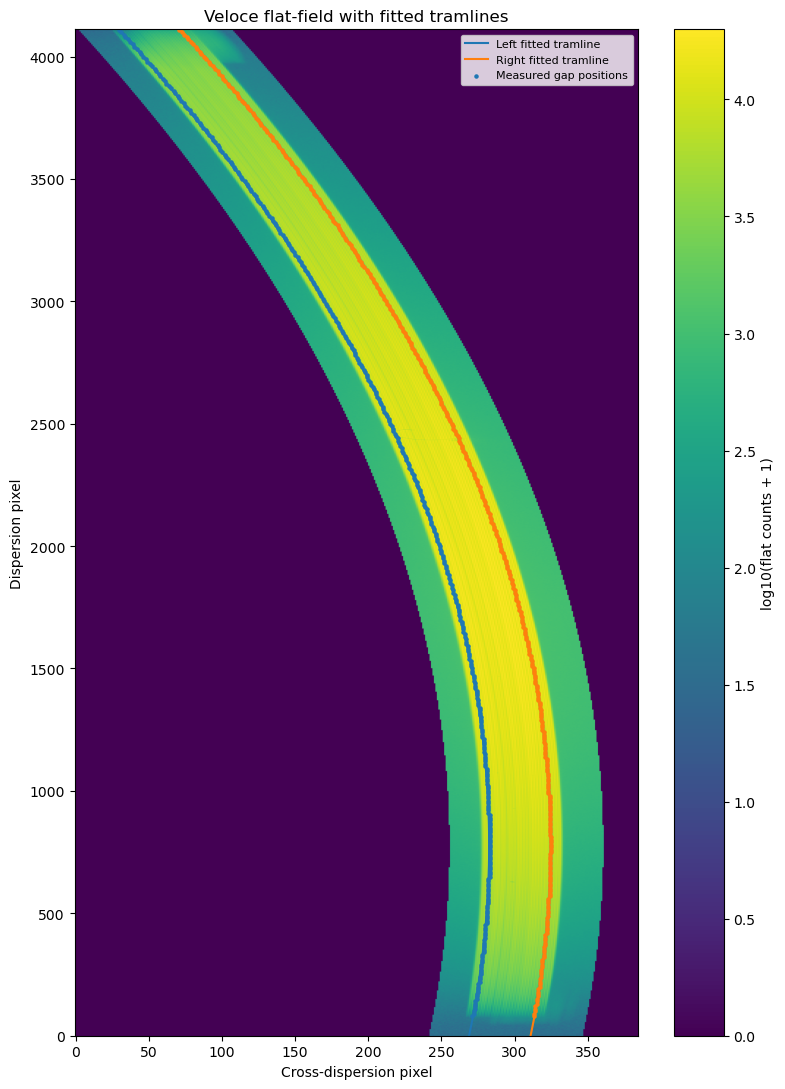


Tramline figure saved to: figures/section4_fitted_tramlines.png

QUESTION 2: SPECTRUM EXTRACTION
Flat spectrum length:      4112 pixels
Moon spectrum length:      4112 pixels
Valid Moon/flat pixels:    4112

Ca II triplet pixels:
Ca II 8498 Å -> pixel 3625
Ca II 8542 Å -> pixel 2789
Ca II 8662 Å -> pixel 447
Wavelength direction: decreasing with detector pixel
Approximate wavelength scale: -0.0515 Å/pixel


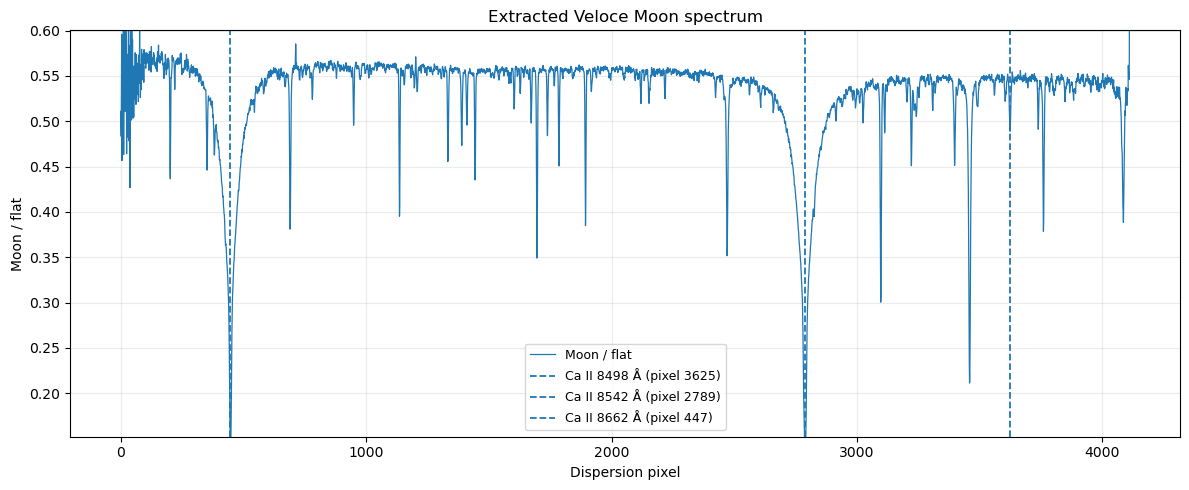


Spectrum figure saved to: figures/section4_moon_flat_spectrum.png

SECTION 4 SUMMARY
Image shape:                   (4112, 385)
Reference row:                 1799
Tramline polynomial degree:    3
Tramline separation:           42.00 pixels
Tramline fit RMS:              0.206 pixels
Valid Moon/flat pixels:        4112
Ca II 8498 Å pixel:            3625
Ca II 8542 Å pixel:            2789
Ca II 8662 Å pixel:            447
Wavelength scale:              -0.0515 Å/pixel
Tramline figure:               figures/section4_fitted_tramlines.png
Spectrum figure:               figures/section4_moon_flat_spectrum.png


In [5]:
# SECTION 4: STELLAR SPECTRUM REDUCTION

import os
import itertools
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks


# SETUP

flat_path = "data/flat.fits"
moon_path = "data/moon.fits"

os.makedirs("figures", exist_ok=True)


# Reading the FITS images.
with fits.open(flat_path) as hdul:
    flat = np.asarray(hdul[0].data, dtype=float)

with fits.open(moon_path) as hdul:
    moon = np.asarray(hdul[0].data, dtype=float)


# Both files must have the same dimensions.
if flat.shape != moon.shape:
    raise ValueError(
        "Flat and Moon images do not have the same shape."
    )


# The dispersion is vertical. Converting to (dispersion, cross-dispersion) if required.
if flat.shape == (385, 4112):
    flat = flat.T
    moon = moon.T


# Replacing invalid values with zero.
flat[~np.isfinite(flat)] = 0.0
moon[~np.isfinite(moon)] = 0.0


n_dispersion, n_cross = flat.shape

dispersion_pixel = np.arange(n_dispersion)


print("=" * 70)
print("SECTION 4: STELLAR SPECTRUM REDUCTION")
print("=" * 70)

print(f"\nImage shape: {flat.shape}")
print(f"Dispersion pixels:       {n_dispersion}")
print(f"Cross-dispersion pixels: {n_cross}")


# QUESTION 1: DETERMINE THE TRAMLINES

# The tramlines are the two narrow low-illumination gaps surrounding the central science fibres.
# Finding the row with the strongest total flat-field signal.
row_sum = np.nansum(flat, axis=1)

reference_row = int(
    np.nanargmax(row_sum)
)


# Averaging a few neighbouring rows to reduce noise.
def make_profile(row, half_width=2):

    start = max(
        0,
        row - half_width
    )

    stop = min(
        n_dispersion,
        row + half_width + 1
    )

    profile = np.nanmedian(
        flat[start:stop],
        axis=0
    )

    # Slight smoothing suppresses pixel-scale noise while preserving the narrow tramline gaps.
    return gaussian_filter1d(
        profile,
        sigma=1.0
    )


reference_profile = make_profile(
    reference_row
)


# Finding the illuminated region of the row.
positive_pixels = np.where(
    reference_profile > 0
)[0]


if len(positive_pixels) == 0:
    raise RuntimeError(
        "No illuminated pixels found in the flat-field."
    )


left_edge = int(
    positive_pixels[0]
)

right_edge = int(
    positive_pixels[-1]
)


# Searching for local minima within the illuminated order.
search_start = left_edge + 5
search_stop = right_edge - 5

search_profile = reference_profile[
    search_start:search_stop
]


profile_range = (
    np.nanmax(search_profile)
    - np.nanmin(search_profile)
)


minima, properties = find_peaks(
    -search_profile,
    prominence=max(
        50.0,
        0.01 * profile_range
    ),
    distance=10
)


# Converting the minima back to detector coordinates.
minima = (
    minima + search_start
)


# Finding pairs of strong minima with a realistic tramline separation.
possible_pairs = []


for i, j in itertools.combinations(
    range(len(minima)),
    2
):

    separation = (
        minima[j]
        - minima[i]
    )

    # A broad range is used so the precise separation is not hard-coded into the tramline-finding procedure.
    if 25 <= separation <= 60:

        strength = (
            properties["prominences"][i]
            + properties["prominences"][j]
        )

        possible_pairs.append(
            (
                strength,
                int(minima[i]),
                int(minima[j])
            )
        )


if len(possible_pairs) == 0:
    raise RuntimeError(
        "Could not identify the initial tramline pair."
    )


# Using the strongest plausible pair.
possible_pairs.sort(
    reverse=True
)

_, left_initial, right_initial = (
    possible_pairs[0]
)


print("\n" + "=" * 70)
print("QUESTION 1: TRAMLINE DETERMINATION")
print("=" * 70)

print(f"Reference row:             {reference_row}")
print(f"Initial left tramline:     {left_initial}")
print(f"Initial right tramline:    {right_initial}")
print(
    f"Initial separation:        "
    f"{right_initial - left_initial} pixels"
)


# TRACK THE TWO TRAMLINES
# Measuring the tramline positions every 10 dispersion pixels.
sample_rows = np.arange(
    0,
    n_dispersion,
    10
)


reference_index = int(
    np.argmin(
        np.abs(
            sample_rows - reference_row
        )
    )
)


left_measured = np.full(
    len(sample_rows),
    np.nan
)

right_measured = np.full(
    len(sample_rows),
    np.nan
)


# Finding the local minimum nearest the expected tramline position.
def nearest_local_minimum(
    profile,
    expected_position,
    window=8
):

    start = max(
        1,
        int(round(expected_position)) - window
    )

    stop = min(
        len(profile) - 1,
        int(round(expected_position)) + window + 1
    )


    section = profile[
        start:stop
    ]


    local_range = (
        np.nanmax(section)
        - np.nanmin(section)
    )


    candidate_minima, _ = find_peaks(
        -section,
        prominence=max(
            1.0,
            0.001 * local_range
        ),
        distance=3
    )


    if len(candidate_minima) > 0:

        candidate_pixels = (
            candidate_minima + start
        )

        nearest = np.argmin(
            np.abs(
                candidate_pixels
                - expected_position
            )
        )

        return float(
            candidate_pixels[nearest]
        )


    # If no minimum is detected, retain the expected position.
    return float(
        round(expected_position)
    )


# Initialise tracking close to the reference row.
profile = make_profile(
    int(
        sample_rows[
            reference_index
        ]
    )
)


left_measured[
    reference_index
] = nearest_local_minimum(
    profile,
    left_initial,
    window=10
)


right_measured[
    reference_index
] = nearest_local_minimum(
    profile,
    right_initial,
    window=10
)


# Tracking towards larger dispersion pixels.
for i in range(
    reference_index + 1,
    len(sample_rows)
):

    profile = make_profile(
        int(
            sample_rows[i]
        )
    )

    left_measured[i] = nearest_local_minimum(
        profile,
        left_measured[i - 1]
    )

    right_measured[i] = nearest_local_minimum(
        profile,
        right_measured[i - 1]
    )


# Tracking towards smaller dispersion pixels.
for i in range(
    reference_index - 1,
    -1,
    -1
):

    profile = make_profile(
        int(
            sample_rows[i]
        )
    )

    left_measured[i] = nearest_local_minimum(
        profile,
        left_measured[i + 1]
    )

    right_measured[i] = nearest_local_minimum(
        profile,
        right_measured[i + 1]
    )


# FIT A SMOOTH FUNCTION TO THE TRAMLINES

measured_separation = (
    right_measured
    - left_measured
)

measured_midpoint = 0.5 * (
    right_measured
    + left_measured
)


median_separation = np.nanmedian(
    measured_separation
)


# Keeping measurements that preserve an approximately constant distance between the two tramlines.
good = (
    np.isfinite(
        measured_midpoint
    )
    &
    np.isfinite(
        measured_separation
    )
    &
    (
        np.abs(
            measured_separation
            - median_separation
        )
        <= 3
    )
    &
    (
        sample_rows >= 50
    )
)


# Scaling detector position before polynomial fitting.
scaled_sample = (
    (
        sample_rows
        - sample_rows.mean()
    )
    /
    (
        sample_rows.max()
        - sample_rows.min()
    )
    * 2
)


# A cubic is flexible enough to follow the smooth curvature.
polynomial_degree = 3


# Rejecting occasional badly tracked measurements.
for iteration in range(5):

    coefficients = np.polyfit(
        scaled_sample[good],
        measured_midpoint[good],
        polynomial_degree
    )


    midpoint_fit = np.polyval(
        coefficients,
        scaled_sample
    )


    residual = (
        measured_midpoint
        - midpoint_fit
    )


    residual_median = np.nanmedian(
        residual[good]
    )


    residual_mad = (
        1.4826
        * np.nanmedian(
            np.abs(
                residual[good]
                - residual_median
            )
        )
    )


    tolerance = max(
        0.75,
        4 * residual_mad
    )


    new_good = (
        good
        &
        (
            np.abs(
                residual
                - residual_median
            )
            < tolerance
        )
    )


    if np.array_equal(
        new_good,
        good
    ):
        break


    good = new_good


# Final fit using the accepted measurements.
coefficients = np.polyfit(
    scaled_sample[good],
    measured_midpoint[good],
    polynomial_degree
)


midpoint_fit = np.polyval(
    coefficients,
    scaled_sample
)


fit_residual = (
    measured_midpoint
    - midpoint_fit
)


tramline_fit_rms = np.sqrt(
    np.mean(
        fit_residual[good] ** 2
    )
)


# Using the measured median separation as the constant width.
tramline_separation = np.nanmedian(
    measured_separation[good]
)


# Evaluating the fitted tramlines at every dispersion pixel.
full_rows = np.arange(
    n_dispersion
)


scaled_full = (
    (
        full_rows
        - sample_rows.mean()
    )
    /
    (
        sample_rows.max()
        - sample_rows.min()
    )
    * 2
)


fitted_midpoint = np.polyval(
    coefficients,
    scaled_full
)


left_tramline = (
    fitted_midpoint
    - tramline_separation / 2
)


right_tramline = (
    fitted_midpoint
    + tramline_separation / 2
)


print(
    f"Accepted tracking points:  "
    f"{good.sum()} / {len(good)}"
)

print(
    f"Polynomial degree:         "
    f"{polynomial_degree}"
)

print(
    f"Tramline separation:       "
    f"{tramline_separation:.2f} pixels"
)

print(
    f"Midpoint fit RMS:          "
    f"{tramline_fit_rms:.3f} pixels"
)


# PLOT FLAT WITH FITTED TRAMLINES
# Log scaling makes the low-illumination gaps easier to see.
flat_display = np.log10(
    np.clip(flat, 0, None) + 1
)


fig, ax = plt.subplots(
    figsize=(8, 11)
)


image = ax.imshow(
    flat_display,
    origin="lower",
    aspect="auto"
)


ax.plot(
    left_tramline,
    dispersion_pixel,
    linewidth=1.5,
    label="Left fitted tramline"
)


ax.plot(
    right_tramline,
    dispersion_pixel,
    linewidth=1.5,
    label="Right fitted tramline"
)


# Showing the measured positions used to constrain the fit.
ax.scatter(
    left_measured[good],
    sample_rows[good],
    s=5,
    label="Measured gap positions"
)


ax.scatter(
    right_measured[good],
    sample_rows[good],
    s=5
)


ax.set_xlabel(
    "Cross-dispersion pixel"
)

ax.set_ylabel(
    "Dispersion pixel"
)

ax.set_title(
    "Veloce flat-field with fitted tramlines"
)


ax.legend(
    fontsize=8
)


fig.colorbar(
    image,
    ax=ax,
    label="log10(flat counts + 1)"
)


plt.tight_layout()


tramline_figure = (
    "figures/"
    "section4_fitted_tramlines.png"
)


plt.savefig(
    tramline_figure,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    f"\nTramline figure saved to: "
    f"{tramline_figure}"
)


# QUESTION 2: EXTRACT THE SPECTRUM

# Sum the counts between the two fitted tramlines.
def extract_between_tramlines(
    image,
    left,
    right
):

    spectrum = np.full(
        image.shape[0],
        np.nan
    )


    for row in range(
        image.shape[0]
    ):

        # Staying just inside the low-illumination gaps.
        first_pixel = max(
            0,
            int(
                np.ceil(
                    left[row]
                )
            )
            + 1
        )


        final_pixel = min(
            image.shape[1],
            int(
                np.floor(
                    right[row]
                )
            )
        )


        if final_pixel > first_pixel:

            spectrum[row] = np.nansum(
                image[
                    row,
                    first_pixel:
                    final_pixel
                ]
            )


    return spectrum


flat_spectrum = extract_between_tramlines(
    flat,
    left_tramline,
    right_tramline
)


moon_spectrum = extract_between_tramlines(
    moon,
    left_tramline,
    right_tramline
)


# DIVIDING MOON BY FLAT

flat_scale = np.nanmedian(
    np.abs(
        flat_spectrum[
            np.isfinite(
                flat_spectrum
            )
        ]
    )
)


valid = (
    np.isfinite(
        flat_spectrum
    )
    &
    np.isfinite(
        moon_spectrum
    )
    &
    (
        np.abs(
            flat_spectrum
        )
        >
        max(
            1e-12,
            1e-8 * flat_scale
        )
    )
)


moon_flat_ratio = np.full(
    n_dispersion,
    np.nan
)


moon_flat_ratio[valid] = (
    moon_spectrum[valid]
    /
    flat_spectrum[valid]
)


n_valid = int(
    np.sum(
        np.isfinite(
            moon_flat_ratio
        )
    )
)


print("\n" + "=" * 70)
print("QUESTION 2: SPECTRUM EXTRACTION")
print("=" * 70)

print(
    f"Flat spectrum length:      "
    f"{len(flat_spectrum)} pixels"
)

print(
    f"Moon spectrum length:      "
    f"{len(moon_spectrum)} pixels"
)

print(
    f"Valid Moon/flat pixels:    "
    f"{n_valid}"
)


if n_valid < 100:
    raise RuntimeError(
        "Too few valid Moon/flat pixels."
    )


# IDENTIFY THE Ca II TRIPLET

# The three broad Ca II absorption features were identified in the extracted Moon/flat spectrum using their expected relative wavelength spacing.

ca_pixels = {
    8498: 3625,
    8542: 2789,
    8662: 447
}


# Wavelength decreases as detector pixel increases.
wavelength_direction = "decreasing"


print("\nCa II triplet pixels:")

print(
    f"Ca II 8498 Å -> "
    f"pixel {ca_pixels[8498]}"
)

print(
    f"Ca II 8542 Å -> "
    f"pixel {ca_pixels[8542]}"
)

print(
    f"Ca II 8662 Å -> "
    f"pixel {ca_pixels[8662]}"
)

print(
    f"Wavelength direction: "
    f"{wavelength_direction} with detector pixel"
)


# Checking the approximate wavelength scale from the three lines.
ca_pixel_array = np.array(
    [
        ca_pixels[8498],
        ca_pixels[8542],
        ca_pixels[8662]
    ],
    dtype=float
)


ca_wavelength_array = np.array(
    [
        8498.0,
        8542.0,
        8662.0
    ]
)


wavelength_coefficients = np.polyfit(
    ca_pixel_array,
    ca_wavelength_array,
    1
)


angstrom_per_pixel = (
    wavelength_coefficients[0]
)


print(
    f"Approximate wavelength scale: "
    f"{angstrom_per_pixel:.4f} Å/pixel"
)


# PLOT THE EXTRACTED MOON / FLAT SPECTRUM

fig, ax = plt.subplots(
    figsize=(12, 5)
)


ax.plot(
    dispersion_pixel,
    moon_flat_ratio,
    linewidth=0.9,
    label="Moon / flat"
)


# Marking the three Ca II absorption lines.
for wavelength in [
    8498,
    8542,
    8662
]:

    pixel = (
        ca_pixels[
            wavelength
        ]
    )


    ax.axvline(
        pixel,
        linestyle="--",
        linewidth=1.3,
        label=(
            f"Ca II {wavelength} Å "
            f"(pixel {pixel})"
        )
    )


ax.set_xlabel(
    "Dispersion pixel"
)

ax.set_ylabel(
    "Moon / flat"
)

ax.set_title(
    "Extracted Veloce Moon spectrum"
)


ax.grid(
    alpha=0.25
)


ax.legend(
    fontsize=9
)


# Robust limits prevent isolated detector pixels from controlling the plot range.
finite_values = moon_flat_ratio[
    np.isfinite(
        moon_flat_ratio
    )
]


ax.set_ylim(
    np.percentile(
        finite_values,
        0.2
    ),
    np.percentile(
        finite_values,
        99.8
    )
)


plt.tight_layout()


spectrum_figure = (
    "figures/"
    "section4_moon_flat_spectrum.png"
)


plt.savefig(
    spectrum_figure,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    f"\nSpectrum figure saved to: "
    f"{spectrum_figure}"
)


# SUMMARY

print("\n" + "=" * 70)
print("SECTION 4 SUMMARY")
print("=" * 70)

print(
    f"Image shape:                   "
    f"{flat.shape}"
)

print(
    f"Reference row:                 "
    f"{reference_row}"
)

print(
    f"Tramline polynomial degree:    "
    f"{polynomial_degree}"
)

print(
    f"Tramline separation:           "
    f"{tramline_separation:.2f} pixels"
)

print(
    f"Tramline fit RMS:              "
    f"{tramline_fit_rms:.3f} pixels"
)

print(
    f"Valid Moon/flat pixels:        "
    f"{n_valid}"
)

print(
    f"Ca II 8498 Å pixel:            "
    f"{ca_pixels[8498]}"
)

print(
    f"Ca II 8542 Å pixel:            "
    f"{ca_pixels[8542]}"
)

print(
    f"Ca II 8662 Å pixel:            "
    f"{ca_pixels[8662]}"
)

print(
    f"Wavelength scale:              "
    f"{angstrom_per_pixel:.4f} Å/pixel"
)

print(
    f"Tramline figure:               "
    f"{tramline_figure}"
)

print(
    f"Spectrum figure:               "
    f"{spectrum_figure}"
)

## Results

### Question 1: Tramlines

The tramlines were identified as the two low-illumination gaps surrounding the central science fibres in the flat-field image. I measured their positions at regularly spaced dispersion pixels and fitted the midpoint with a third-order polynomial. The distance between the two tramlines was held constant.

The fitted tramlines have a separation of approximately **42 pixels** and the RMS scatter of the midpoint fit is approximately **0.21 pixels**. The fitted curves closely follow the two gaps across the detector.

### Question 2: Spectrum extraction

The flat-field and Moon spectra were extracted by summing the counts between the fitted tramlines for each dispersion pixel. Dividing the Moon spectrum by the flat spectrum removes the illumination response and produces the extracted Moon spectrum.

The Ca II triplet absorption lines were identified at approximately:

- Ca II 8498 Å: **pixel 3625**
- Ca II 8542 Å: **pixel 2789**
- Ca II 8662 Å: **pixel 447**

Wavelength therefore decreases with increasing dispersion pixel across this detector region.